--- Resumo Funcional: Ferramenta vs Referência ---


Category,Both Informative,Both Hypothetical,Over-Annotation,Under-Annotation
Tool,,,,
Bakta,2947,567,425,401
PGAP,3126,239,753,222
Prokka,2622,661,331,726
eggNOG,2934,345,647,414


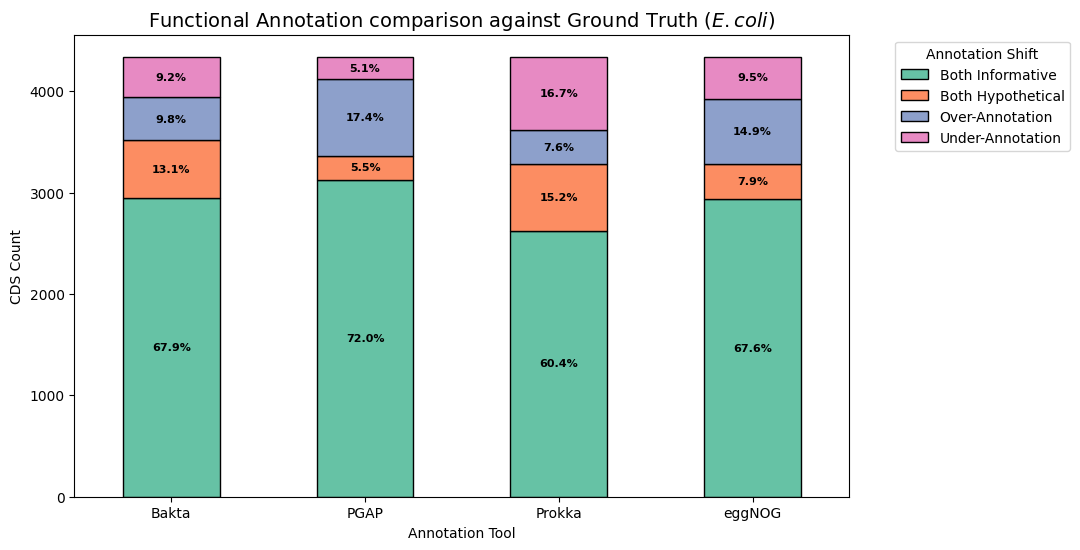

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_func = pd.read_csv("ecoli_data/e_coli_concordant_CDS.csv")

def is_informative(product_text):
    if pd.isna(product_text):
        return False
        
    text = str(product_text).lower().strip()
    
    vague_terms = ['hypothetical', 'uncharacterized', 'unknown', 'putative', 'duf', 'domain of unknown function']
    
    if any(term in text for term in vague_terms) or text == '':
        return False
    
    return True

tools = ['Reference', 'Prokka', 'Bakta', 'PGAP', 'eggNOG']
for tool in tools:
    col_name = f'product_{tool}'
    info_col = f'is_info_{tool}'
    df_func[info_col] = df_func[col_name].apply(is_informative)

comparison_results = []
tools_to_evaluate = ['Prokka', 'Bakta', 'PGAP', 'eggNOG']

for tool in tools_to_evaluate:
    tool_info = df_func[f'is_info_{tool}']
    ref_info = df_func['is_info_Reference']
    
    for i in range(len(df_func)):
        t_val = tool_info.iloc[i]
        r_val = ref_info.iloc[i]
        
        if t_val == True and r_val == True:
            category = 'Both Informative'
        elif t_val == False and r_val == False:
            category = 'Both Hypothetical'
        elif t_val == True and r_val == False:
            category = 'Over-Annotation'
        elif t_val == False and r_val == True:
            category = 'Under-Annotation'
            
        comparison_results.append({
            'Tool': tool,
            'Category': category
        })

df_plot = pd.DataFrame(comparison_results)
summary_table = df_plot.groupby(['Tool', 'Category']).size().unstack(fill_value=0)

col_order = ['Both Informative', 'Both Hypothetical', 'Over-Annotation', 'Under-Annotation']
summary_table = summary_table[col_order]

print("--- Resumo Funcional: Ferramenta vs Referência ---")
display(summary_table)
custom_color_map = {
    'Both Informative': '#66c2a5',  
    'Both Hypothetical': '#fc8d62', 
    'Over-Annotation': '#8da0cb',  
    'Under-Annotation': '#e78ac3'    
}
summary_table.plot(kind='bar', stacked=True, figsize=(10, 6), color=[custom_color_map[cat] for cat in summary_table.columns], edgecolor='black')
plt.title("Functional Annotation comparison against Ground Truth ($\it{E. coli}$)", fontsize=14)
plt.ylabel("CDS Count")
plt.xlabel("Annotation Tool")
plt.xticks(rotation=0)
plt.legend(title="Annotation Shift",
           bbox_to_anchor=(1.05, 1),
           loc='upper left')
total = summary_table.sum(axis=1).iloc[0]
ax = plt.gca()

for idx, container in enumerate(ax.containers):
    labels = [f'{v/total*100:.1f}%' for v in container.datavalues]
    text_objs = ax.bar_label(container, labels=labels,
                             label_type='center',
                             fontsize=8,
                             fontweight='bold')